In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import make_scorer,mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
from scipy.stats import f
from statsmodels.stats.stattools import durbin_watson
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error

In [2]:
!gdown --id 1qozRwXEWK4lQiAF1iqmNgeDoYO3GKKAh

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1qozRwXEWK4lQiAF1iqmNgeDoYO3GKKAh
To: /content/crop_yield_dataset.csv
100% 4.74M/4.74M [00:00<00:00, 27.8MB/s]


In [3]:
dataset = pd.read_csv('crop_yield_dataset.csv')

In [4]:
print(dataset)

             Date  Crop_Type Soil_Type  Soil_pH  Temperature   Humidity  \
0      2014-01-01      Wheat     Peaty     5.50     9.440599  80.000000   
1      2014-01-01       Corn     Loamy     6.50    20.052576  79.947424   
2      2014-01-01       Rice     Peaty     5.50    12.143099  80.000000   
3      2014-01-01     Barley     Sandy     6.75    19.751848  80.000000   
4      2014-01-01    Soybean     Peaty     5.50    16.110395  80.000000   
...           ...        ...       ...      ...          ...        ...   
36515  2023-12-31     Cotton      Clay     6.25    19.538555  80.000000   
36516  2023-12-31  Sugarcane     Peaty     5.50    21.068336  78.931664   
36517  2023-12-31     Tomato     Sandy     6.75     6.030148  80.000000   
36518  2023-12-31     Potato     Peaty     5.50    11.079561  80.000000   
36519  2023-12-31  Sunflower      Clay     6.25    11.455692  80.000000   

       Wind_Speed     N     P     K  Crop_Yield  Soil_Quality  
0       10.956707  60.5  45.0  31.5

In [5]:
dataset.describe(include=['object'])

,Date,Crop_Type,Soil_Type
count,36520,36520,36520
unique,3652,10,5
top,2023-12-31,Wheat,Saline
freq,10,3652,7361


In [6]:
dataset['Date'] = pd.to_datetime(dataset['Date'])

In [7]:
dataset.set_index('Date', inplace=True)

In [8]:
dataset.head()

,Crop_Type,Soil_Type,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality
Date,,,,,,,,,,,
2014-01-01,Wheat,Peaty,5.50,9.440599,80.000000,10.956707,60.5,45.0,31.5,0.000000,22.833333
2014-01-01,Corn,Loamy,6.50,20.052576,79.947424,8.591577,84.0,66.0,50.0,104.871310,66.666667
2014-01-01,Rice,Peaty,5.50,12.143099,80.000000,7.227751,71.5,54.0,38.5,0.000000,27.333333
2014-01-01,Barley,Sandy,6.75,19.751848,80.000000,2.682683,50.0,40.0,30.0,58.939796,35.000000
2014-01-01,Soybean,Peaty,5.50,16.110395,80.000000,7.696070,49.5,45.0,38.5,32.970413,22.166667


In [9]:
dataset.drop('Wind_Speed', axis=1, inplace=True)
dataset.drop('Soil_Type', axis=1, inplace=True)

In [10]:
def preprocess_dataset(dataset, crop_type):
    dataset_filtered = dataset[dataset['Crop_Type'] == crop_type]

    columns_to_drop = ['Crop_Type']
    dataset_filtered = dataset_filtered.drop(columns=columns_to_drop, axis=1)

    return dataset_filtered
def prepare_data(dataset):
    features = dataset[['Crop_Yield', 'Soil_pH', 'Temperature', 'Humidity', 'N', 'P', 'K', 'Soil_Quality']].values

    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_features = scaler.fit_transform(features)

    train_size = int(len(scaled_features) * 0.7)
    test_size = len(scaled_features) - train_size
    train, test = scaled_features[0:train_size], scaled_features[train_size:len(dataset)]

    print(f'Train size: {len(train)}, Test size: {len(test)}')

    return train, test, scaler, scaled_features
def create_dataset(data, look_back):
    dataX, dataY = [], []
    for i in range(len(data) - look_back):
        a = data[i:(i + look_back)]
        dataX.append(a)
        dataY.append(data[i + look_back, 0])
    return np.array(dataX), np.array(dataY)
def r2(y_true, y_pred):
    ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
    ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
    return (1 - ss_res / (ss_tot + tf.keras.backend.epsilon()))
def scale_target(dataset):
    target = dataset['Crop_Yield'].values
    scaler_y = MinMaxScaler(feature_range=(0, 1))
    target_scaled = scaler_y.fit_transform(target.reshape(-1, 1))

    return scaler_y
def predict_and_inverse_transform(model, trainX, testX, train, test, scaler):
    trainPredict = model.predict(trainX)
    testPredict = model.predict(testX)

    trainPredict = scaler.inverse_transform(np.concatenate((trainPredict, train[:len(trainPredict), 1:]), axis=1))[:, 0]
    testPredict = scaler.inverse_transform(np.concatenate((testPredict, test[:len(testPredict), 1:]), axis=1))[:, 0]

    return trainPredict, testPredict
def evaluate_predictions(trainPredict, testPredict, trainY, testY, scaler_y):
    print(np.sqrt(mean_squared_error(testPredict, scaler_y.inverse_transform(testY.reshape(-1, 1)))))
    print(r2_score(testPredict, scaler_y.inverse_transform(testY.reshape(-1, 1))))
    print(np.sqrt(mean_squared_error(trainPredict, scaler_y.inverse_transform(trainY.reshape(-1, 1)))))
    print(r2_score(trainPredict, scaler_y.inverse_transform(trainY.reshape(-1, 1))))

#tomato

In [ ]:
dataset_t=preprocess_dataset(dataset, 'Tomato')

In [ ]:
dataset_t.corr()

,Soil_pH,Temperature,Humidity,N,P,K,Crop_Yield,Soil_Quality
Soil_pH,1.000000,0.022616,-0.012137,0.341504,0.341504,0.341504,0.008043,-0.339529
Temperature,0.022616,1.000000,-0.943600,0.005851,0.005851,0.005851,0.028188,-0.004490
Humidity,-0.012137,-0.943600,1.000000,-0.008635,-0.008635,-0.008635,0.206703,-0.000400
N,0.341504,0.005851,-0.008635,1.000000,1.000000,1.000000,0.158905,0.351337
P,0.341504,0.005851,-0.008635,1.000000,1.000000,1.000000,0.158905,0.351337
K,0.341504,0.005851,-0.008635,1.000000,1.000000,1.000000,0.158905,0.351337
Crop_Yield,0.008043,0.028188,0.206703,0.158905,0.158905,0.158905,1.000000,0.182942
Soil_Quality,-0.339529,-0.004490,-0.000400,0.351337,0.351337,0.351337,0.182942,1.000000


In [ ]:
print(dataset_t)

            Soil_pH  Temperature   Humidity     N     P     K  Crop_Yield  \
Date                                                                        
2014-01-01     6.25    18.323272  80.000000  60.0  45.0  40.0   22.221375   
2014-01-02     6.25    19.877726  80.000000  60.0  45.0  40.0   31.009611   
2014-01-03     6.50    17.304778  80.000000  70.0  54.0  50.0   19.466158   
2014-01-04     6.75    15.384475  80.000000  50.0  36.0  30.0    1.864858   
2014-01-05     6.50     5.327149  80.000000  70.0  54.0  50.0    0.000000   
...             ...          ...        ...   ...   ...   ...         ...   
2023-12-27     5.50    14.868981  80.000000  55.0  40.5  35.0    0.000000   
2023-12-28     6.50    14.665130  80.000000  70.0  54.0  50.0    0.000000   
2023-12-29     6.25    10.082282  80.000000  60.0  45.0  40.0    0.000000   
2023-12-30     5.50    20.021899  79.978101  55.0  40.5  35.0   29.620297   
2023-12-31     6.75     6.030148  80.000000  50.0  36.0  30.0    0.000000   

In [ ]:
monthly_yield_t = dataset_t.resample('M').median()

<ipython-input-18-881fbe6e430d>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_yield_t = dataset_t.resample('M').median()


In [ ]:
monthly_yield_t

,Soil_pH,Temperature,Humidity,N,P,K,Crop_Yield,Soil_Quality
Date,,,,,,,,
2014-01-31,6.750,14.075489,80.000000,60.0,45.0,40.0,0.000000,33.833333
2014-02-28,6.500,16.049299,80.000000,60.0,45.0,40.0,5.413446,27.791667
2014-03-31,6.500,25.221340,74.778660,60.0,45.0,40.0,33.829607,21.750000
2014-04-30,6.500,22.268962,77.731038,60.0,45.0,40.0,38.807243,38.062500
2014-05-31,6.500,26.115765,73.884235,60.0,45.0,40.0,33.715057,42.291667
...,...,...,...,...,...,...,...,...
2023-08-31,6.250,36.786063,63.213937,55.0,40.5,35.0,0.000000,33.833333
2023-09-30,6.375,21.741315,78.258685,60.0,45.0,40.0,37.097053,33.833333
2023-10-31,6.500,19.582143,80.000000,60.0,45.0,40.0,25.628164,33.833333


# potato

In [ ]:
dataset_p=preprocess_dataset(dataset, 'Potato')

In [ ]:
print(dataset_p)

            Soil_pH  Temperature   Humidity     N     P     K  Crop_Yield  \
Date                                                                        
2014-01-01     5.50    18.895963  80.000000  60.5  45.0  31.5   54.259727   
2014-01-02     8.00    19.062629  80.000000  71.5  55.0  40.5   52.589622   
2014-01-03     6.75    10.648475  80.000000  55.0  40.0  27.0    3.265646   
2014-01-04     8.00    12.917718  80.000000  71.5  55.0  40.5   18.278763   
2014-01-05     6.75    14.975715  80.000000  55.0  40.0  27.0   27.500608   
...             ...          ...        ...   ...   ...   ...         ...   
2023-12-27     6.75    23.041461  76.958539  55.0  40.0  27.0   37.132201   
2023-12-28     5.50    18.764783  80.000000  60.5  45.0  31.5   44.034011   
2023-12-29     6.25    20.584080  79.415920  66.0  50.0  36.0   63.269236   
2023-12-30     5.50    11.160270  80.000000  60.5  45.0  31.5    6.207438   
2023-12-31     5.50    11.079561  80.000000  60.5  45.0  31.5    6.067881   

In [ ]:
monthly_yield_p = dataset_p.resample('M').median()

<ipython-input-345-1318b0921f72>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_yield_p = dataset_p.resample('M').median()


In [ ]:
monthly_yield_p

,Soil_pH,Temperature,Humidity,N,P,K,Crop_Yield,Soil_Quality
Date,,,,,,,,
2014-01-31,6.500,18.213614,80.000000,66.00,50.0,36.00,43.158219,35.583333
2014-02-28,6.375,15.797205,80.000000,63.25,47.5,33.75,34.976042,35.583333
2014-03-31,6.500,24.664109,75.335891,71.50,55.0,40.50,34.460227,35.583333
2014-04-30,6.375,26.769673,73.230327,60.50,45.0,31.50,20.435456,22.833333
2014-05-31,6.750,24.938862,75.061138,66.00,50.0,36.00,30.389927,35.583333
...,...,...,...,...,...,...,...,...
2023-08-31,6.500,34.378515,65.621485,66.00,50.0,36.00,0.000000,35.583333
2023-09-30,6.500,20.803633,79.196367,66.00,50.0,36.00,44.423647,35.583333
2023-10-31,6.500,20.137804,79.862196,66.00,50.0,36.00,45.822082,22.833333


#Corn

In [ ]:
dataset_c=preprocess_dataset(dataset, 'Corn')

In [ ]:
dataset_c.corr()

,Soil_pH,Temperature,Humidity,N,P,K,Crop_Yield,Soil_Quality
Soil_pH,1.000000,-0.019498,0.028618,0.346965,0.346965,0.346965,0.018961,-0.338020
Temperature,-0.019498,1.000000,-0.939617,-0.011994,-0.011994,-0.011994,-0.419076,0.000019
Humidity,0.028618,-0.939617,1.000000,0.018827,0.018827,0.018827,0.647640,0.000802
N,0.346965,-0.011994,0.018827,1.000000,1.000000,1.000000,0.180311,0.352652
P,0.346965,-0.011994,0.018827,1.000000,1.000000,1.000000,0.180311,0.352652
K,0.346965,-0.011994,0.018827,1.000000,1.000000,1.000000,0.180311,0.352652
Crop_Yield,0.018961,-0.419076,0.647640,0.180311,0.180311,0.180311,1.000000,0.182936
Soil_Quality,-0.338020,0.000019,0.000802,0.352652,0.352652,0.352652,0.182936,1.000000


In [ ]:
print(dataset_c)

            Soil_pH  Temperature   Humidity     N     P     K  Crop_Yield  \
Date                                                                        
2014-01-01     6.50    20.052576  79.947424  84.0  66.0  50.0  104.871310   
2014-01-02     6.25    15.984306  80.000000  72.0  55.0  40.0   51.656273   
2014-01-03     5.50    13.504963  80.000000  66.0  49.5  35.0   22.325127   
2014-01-04     6.75    22.019794  77.980206  60.0  44.0  30.0   46.616260   
2014-01-05     6.25    13.389692  80.000000  72.0  55.0  40.0   23.579097   
...             ...          ...        ...   ...   ...   ...         ...   
2023-12-27     5.50    13.936109  80.000000  66.0  49.5  35.0   26.911401   
2023-12-28     6.50    16.451228  80.000000  84.0  66.0  50.0   69.535777   
2023-12-29     5.50     8.516808  80.000000  66.0  49.5  35.0    0.000000   
2023-12-30     6.50    13.500750  80.000000  84.0  66.0  50.0   34.842371   
2023-12-31     8.00    13.079635  80.000000  78.0  60.5  45.0   20.735135   

In [ ]:
monthly_yield_c = dataset_c.resample('M').median()

<ipython-input-441-2bb21458d4cd>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_yield_c = dataset_c.resample('M').median()


In [ ]:
monthly_yield_c

,Soil_pH,Temperature,Humidity,N,P,K,Crop_Yield,Soil_Quality
Date,,,,,,,,
2014-01-31,6.500,16.021415,80.000000,72.0,55.00,40.0,45.099133,48.708333
2014-02-28,6.375,14.915285,80.000000,69.0,52.25,37.5,34.433523,25.083333
2014-03-31,6.500,24.907537,75.092463,72.0,55.00,40.0,35.395377,39.083333
2014-04-30,6.625,24.106159,75.893841,69.0,52.25,37.5,37.454296,25.083333
2014-05-31,6.750,25.946017,74.053983,78.0,60.50,45.0,24.504714,39.083333
...,...,...,...,...,...,...,...,...
2023-08-31,6.250,34.382614,65.617386,72.0,55.00,40.0,0.000000,25.083333
2023-09-30,6.500,19.238285,80.000000,72.0,55.00,40.0,46.768186,39.083333
2023-10-31,6.500,20.216920,79.783080,72.0,55.00,40.0,54.309297,39.083333


#Wheat

In [ ]:
dataset_w=preprocess_dataset(dataset, 'Wheat')

In [ ]:
dataset_w.corr()

,Soil_pH,Temperature,Humidity,N,P,K,Crop_Yield,Soil_Quality
Soil_pH,1.000000,0.017441,-0.013206,0.342536,0.342536,0.342536,-0.011716,-0.326309
Temperature,0.017441,1.000000,-0.939267,0.018114,0.018114,0.018114,-0.422510,0.009319
Humidity,-0.013206,-0.939267,1.000000,-0.016387,-0.016387,-0.016387,0.649766,-0.011434
N,0.342536,0.018114,-0.016387,1.000000,1.000000,1.000000,0.147856,0.352145
P,0.342536,0.018114,-0.016387,1.000000,1.000000,1.000000,0.147856,0.352145
K,0.342536,0.018114,-0.016387,1.000000,1.000000,1.000000,0.147856,0.352145
Crop_Yield,-0.011716,-0.422510,0.649766,0.147856,0.147856,0.147856,1.000000,0.178384
Soil_Quality,-0.326309,0.009319,-0.011434,0.352145,0.352145,0.352145,0.178384,1.000000


In [ ]:
print(dataset_w)

            Soil_pH  Temperature  Humidity     N     P     K  Crop_Yield  \
Date                                                                       
2014-01-01     5.50     9.440599  80.00000  60.5  45.0  31.5    0.000000   
2014-01-02     5.50    16.044318  80.00000  60.5  45.0  31.5   28.723530   
2014-01-03     6.50     1.901274  80.00000  77.0  60.0  45.0    0.000000   
2014-01-04     6.50    16.074694  80.00000  77.0  60.0  45.0   50.066525   
2014-01-05     6.75    10.402879  80.00000  55.0  40.0  27.0    2.151818   
...             ...          ...       ...   ...   ...   ...         ...   
2023-12-27     5.50    18.183474  80.00000  60.5  45.0  31.5   44.789833   
2023-12-28     6.50    22.897860  77.10214  77.0  60.0  45.0   68.179570   
2023-12-29     6.25    13.076644  80.00000  66.0  50.0  36.0   16.314931   
2023-12-30     8.00    10.447340  80.00000  71.5  55.0  40.5    2.470289   
2023-12-31     5.50     4.334143  80.00000  60.5  45.0  31.5    0.000000   

           

In [ ]:
monthly_yield_w = dataset_w.resample('M').median()

<ipython-input-18-624068dc3864>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_yield_w = dataset_w.resample('M').median()


In [ ]:
monthly_yield_w

,Soil_pH,Temperature,Humidity,N,P,K,Crop_Yield,Soil_Quality
Date,,,,,,,,
2014-01-31,6.500,15.298152,80.000000,60.5,45.0,31.5,28.723530,35.583333
2014-02-28,6.750,15.710256,80.000000,66.0,50.0,36.0,33.036295,35.583333
2014-03-31,6.250,26.321489,73.678511,66.0,50.0,36.0,24.014009,44.333333
2014-04-30,6.500,25.430494,74.569506,66.0,50.0,36.0,25.799821,35.583333
2014-05-31,6.500,25.207010,74.792990,66.0,50.0,36.0,28.171200,35.583333
...,...,...,...,...,...,...,...,...
2023-08-31,6.500,34.530574,65.469426,66.0,50.0,36.0,0.000000,35.583333
2023-09-30,6.375,19.586776,80.000000,66.0,50.0,36.0,35.739666,44.333333
2023-10-31,6.750,20.519061,79.480939,66.0,50.0,36.0,46.986583,35.583333


#Sunflower

In [ ]:
dataset_s=preprocess_dataset(dataset, 'Sunflower')

In [ ]:
dataset_s.corr()

,Soil_pH,Temperature,Humidity,N,P,K,Crop_Yield,Soil_Quality
Soil_pH,1.000000,0.017686,-0.012531,0.338239,0.338239,0.338239,-0.015504,-0.320532
Temperature,0.017686,1.000000,-0.941022,0.009260,0.009260,0.009260,-0.434568,-0.001268
Humidity,-0.012531,-0.941022,1.000000,-0.012871,-0.012871,-0.012871,0.656570,-0.004309
N,0.338239,0.009260,-0.012871,1.000000,1.000000,1.000000,0.160075,0.378314
P,0.338239,0.009260,-0.012871,1.000000,1.000000,1.000000,0.160075,0.378314
K,0.338239,0.009260,-0.012871,1.000000,1.000000,1.000000,0.160075,0.378314
Crop_Yield,-0.015504,-0.434568,0.656570,0.160075,0.160075,0.160075,1.000000,0.195443
Soil_Quality,-0.320532,-0.001268,-0.004309,0.378314,0.378314,0.378314,0.195443,1.000000


In [ ]:
print(dataset_s)

            Soil_pH  Temperature   Humidity     N     P     K  Crop_Yield  \
Date                                                                        
2014-01-01     6.50    16.865595  80.000000  70.0  66.0  55.0   68.119250   
2014-01-02     8.00    20.017664  79.982336  65.0  60.5  49.5   65.936595   
2014-01-03     6.75    29.718317  70.281683  50.0  44.0  33.0    1.464600   
2014-01-04     6.50    10.242641  80.000000  70.0  66.0  55.0    2.254674   
2014-01-05     6.50     9.437513  80.000000  70.0  66.0  55.0    0.000000   
...             ...          ...        ...   ...   ...   ...         ...   
2023-12-27     8.00    20.581730  79.418270  65.0  60.5  49.5   56.813660   
2023-12-28     6.75    10.437350  80.000000  50.0  44.0  33.0    2.515307   
2023-12-29     6.75    18.803978  80.000000  50.0  44.0  33.0   60.345888   
2023-12-30     6.75    17.735601  80.000000  50.0  44.0  33.0   47.372593   
2023-12-31     6.25    11.455692  80.000000  60.0  55.0  44.0   11.825986   

In [ ]:
monthly_yield_s = dataset_s.resample('M').median()

<ipython-input-112-2d66c25f651d>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_yield_s = dataset_s.resample('M').median()


In [ ]:
monthly_yield_s

,Soil_pH,Temperature,Humidity,N,P,K,Crop_Yield,Soil_Quality
Date,,,,,,,,
2014-01-31,6.500,16.187426,80.000000,60.0,55.00,44.00,23.488705,46.375000
2014-02-28,6.625,15.612599,80.000000,65.0,60.50,49.50,31.149015,23.833333
2014-03-31,6.750,27.457711,72.542289,65.0,60.50,49.50,15.597266,37.041667
2014-04-30,6.500,24.084224,75.915776,57.5,52.25,41.25,40.392049,37.041667
2014-05-31,6.500,25.170040,74.829960,60.0,55.00,44.00,30.028502,37.041667
...,...,...,...,...,...,...,...,...
2023-08-31,6.500,35.075233,64.924767,60.0,55.00,44.00,0.000000,37.041667
2023-09-30,6.500,20.918174,79.081826,60.0,55.00,44.00,49.379542,37.041667
2023-10-31,6.500,21.025048,78.974952,60.0,55.00,44.00,47.956107,37.041667


#Cotton

In [ ]:
dataset_ct=preprocess_dataset(dataset, 'Cotton')

In [ ]:
dataset_ct.corr()

,Soil_pH,Temperature,Humidity,N,P,K,Crop_Yield,Soil_Quality
Soil_pH,1.000000,0.030191,-0.035573,0.347258,0.347258,0.347258,-0.036274,-0.339885
Temperature,0.030191,1.000000,-0.943763,0.008883,0.008883,0.008883,-0.444047,-0.022503
Humidity,-0.035573,-0.943763,1.000000,-0.007399,-0.007399,-0.007399,0.660270,0.022453
N,0.347258,0.008883,-0.007399,1.000000,1.000000,1.000000,0.149848,0.364801
P,0.347258,0.008883,-0.007399,1.000000,1.000000,1.000000,0.149848,0.364801
K,0.347258,0.008883,-0.007399,1.000000,1.000000,1.000000,0.149848,0.364801
Crop_Yield,-0.036274,-0.444047,0.660270,0.149848,0.149848,0.149848,1.000000,0.198297
Soil_Quality,-0.339885,-0.022503,0.022453,0.364801,0.364801,0.364801,0.198297,1.000000


In [ ]:
print(dataset_ct)

            Soil_pH  Temperature   Humidity     N     P     K  Crop_Yield  \
Date                                                                        
2014-01-01     6.75    14.826739  80.000000  55.0  44.0  36.0   29.356115   
2014-01-02     6.50    19.438742  80.000000  77.0  66.0  60.0  108.292731   
2014-01-03     5.50    16.572564  80.000000  60.5  49.5  42.0   39.123236   
2014-01-04     6.50    21.158892  78.841108  77.0  66.0  60.0   83.740585   
2014-01-05     5.50    16.732241  80.000000  60.5  49.5  42.0   44.400611   
...             ...          ...        ...   ...   ...   ...         ...   
2023-12-27     5.50    20.756651  79.243349  60.5  49.5  42.0   54.895175   
2023-12-28     6.25    11.527621  80.000000  66.0  55.0  48.0   11.166276   
2023-12-29     8.00    14.443769  80.000000  71.5  60.5  54.0   31.734084   
2023-12-30     6.50    15.116587  80.000000  77.0  66.0  60.0   46.675684   
2023-12-31     6.25    19.538555  80.000000  66.0  55.0  48.0   73.323885   

In [ ]:
monthly_yield_ct = dataset_ct.resample('M').median()

<ipython-input-18-8753eb2b6f0e>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_yield_ct = dataset_ct.resample('M').median()


In [ ]:
monthly_yield_ct

,Soil_pH,Temperature,Humidity,N,P,K,Crop_Yield,Soil_Quality
Date,,,,,,,,
2014-01-31,6.500,13.624380,80.000000,66.0,55.0,48.0,33.750341,39.375000
2014-02-28,6.500,14.088674,80.000000,66.0,55.0,48.0,22.769627,39.375000
2014-03-31,6.500,24.642004,75.357996,66.0,55.0,48.0,32.891659,39.375000
2014-04-30,6.625,25.374540,74.625460,71.5,60.5,54.0,19.449502,25.333333
2014-05-31,6.250,24.359866,75.640134,66.0,55.0,48.0,32.861926,39.375000
...,...,...,...,...,...,...,...,...
2023-08-31,6.750,35.165814,64.834186,66.0,55.0,48.0,0.000000,39.375000
2023-09-30,6.500,20.834589,79.165411,66.0,55.0,48.0,46.755923,44.333333
2023-10-31,6.500,20.962754,79.037246,71.5,60.5,54.0,42.553204,39.375000


#Rice

In [ ]:
dataset_r=preprocess_dataset(dataset, 'Rice')

In [ ]:
dataset_r.corr()

,Soil_pH,Temperature,Humidity,N,P,K,Crop_Yield,Soil_Quality
Soil_pH,1.000000,0.002577,-0.011629,0.356767,0.356767,0.356767,-0.027554,-0.328975
Temperature,0.002577,1.000000,-0.942268,-0.017668,-0.017668,-0.017668,0.043045,-0.024149
Humidity,-0.011629,-0.942268,1.000000,0.017353,0.017353,0.017353,0.195148,0.028112
N,0.356767,-0.017668,0.017353,1.000000,1.000000,1.000000,0.169965,0.340307
P,0.356767,-0.017668,0.017353,1.000000,1.000000,1.000000,0.169965,0.340307
K,0.356767,-0.017668,0.017353,1.000000,1.000000,1.000000,0.169965,0.340307
Crop_Yield,-0.027554,0.043045,0.195148,0.169965,0.169965,0.169965,1.000000,0.193536
Soil_Quality,-0.328975,-0.024149,0.028112,0.340307,0.340307,0.340307,0.193536,1.000000


In [ ]:
print(dataset_r)

            Soil_pH  Temperature   Humidity     N     P     K  Crop_Yield  \
Date                                                                        
2014-01-01     5.50    12.143099  80.000000  71.5  54.0  38.5    0.000000   
2014-01-02     5.50    14.421759  80.000000  71.5  54.0  38.5    0.000000   
2014-01-03     8.00    12.327918  80.000000  84.5  66.0  49.5    0.000000   
2014-01-04     6.25    11.208364  80.000000  78.0  60.0  44.0    0.000000   
2014-01-05     6.25    15.065169  80.000000  78.0  60.0  44.0    0.566930   
...             ...          ...        ...   ...   ...   ...         ...   
2023-12-27     6.50    13.775894  80.000000  91.0  72.0  55.0    0.000000   
2023-12-28     6.25    11.876830  80.000000  78.0  60.0  44.0    0.000000   
2023-12-29     6.50    26.660243  73.339757  91.0  72.0  55.0   78.800717   
2023-12-30     6.75     9.629740  80.000000  65.0  48.0  33.0    0.000000   
2023-12-31     6.75     3.994628  80.000000  65.0  48.0  33.0    0.000000   

In [ ]:
monthly_yield_r = dataset_r.resample('M').median()

<ipython-input-103-cd0e27bcca95>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_yield_r = dataset_r.resample('M').median()


In [ ]:
monthly_yield_r

,Soil_pH,Temperature,Humidity,N,P,K,Crop_Yield,Soil_Quality
Date,,,,,,,,
2014-01-31,6.500,14.421759,80.000000,78.0,60.0,44.0,0.000000,42.583333
2014-02-28,6.250,15.082433,80.000000,78.0,60.0,44.0,0.567739,42.583333
2014-03-31,6.500,24.479379,75.520621,78.0,60.0,44.0,37.593721,42.583333
2014-04-30,6.500,26.768503,73.231497,78.0,60.0,44.0,35.667703,42.583333
2014-05-31,6.750,24.764449,75.235551,78.0,60.0,44.0,40.425599,42.583333
...,...,...,...,...,...,...,...,...
2023-08-31,6.500,34.089080,65.910920,71.5,54.0,38.5,5.490694,42.583333
2023-09-30,6.625,20.958346,79.041654,78.0,60.0,44.0,39.040174,42.583333
2023-10-31,6.500,20.751660,79.248340,78.0,60.0,44.0,45.328909,42.583333


#Sugarcane

In [ ]:
dataset_sc=preprocess_dataset(dataset, 'Sugarcane')

In [ ]:
dataset_sc.corr()

,Soil_pH,Temperature,Humidity,N,P,K,Crop_Yield,Soil_Quality
Soil_pH,1.000000,0.005830,-0.012011,0.363753,0.363753,0.363753,-0.030956,-0.335378
Temperature,0.005830,1.000000,-0.943847,-0.013619,-0.013619,-0.013619,0.046666,-0.011329
Humidity,-0.012011,-0.943847,1.000000,0.013077,0.013077,0.013077,0.189517,0.010645
N,0.363753,-0.013619,0.013077,1.000000,1.000000,1.000000,0.131054,0.346398
P,0.363753,-0.013619,0.013077,1.000000,1.000000,1.000000,0.131054,0.346398
K,0.363753,-0.013619,0.013077,1.000000,1.000000,1.000000,0.131054,0.346398
Crop_Yield,-0.030956,0.046666,0.189517,0.131054,0.131054,0.131054,1.000000,0.178255
Soil_Quality,-0.335378,-0.011329,0.010645,0.346398,0.346398,0.346398,0.178255,1.000000


In [ ]:
print(dataset_sc)

            Soil_pH  Temperature   Humidity     N     P     K  Crop_Yield  \
Date                                                                        
2014-01-01     8.00    13.533004  80.000000  84.5  66.0  54.0    0.000000   
2014-01-02     6.25    10.803912  80.000000  78.0  60.0  48.0    0.000000   
2014-01-03     6.25    13.361874  80.000000  78.0  60.0  48.0    0.000000   
2014-01-04     8.00    22.026027  77.973973  84.5  66.0  54.0   45.860149   
2014-01-05     6.50    17.834470  80.000000  91.0  72.0  60.0   31.152431   
...             ...          ...        ...   ...   ...   ...         ...   
2023-12-27     8.00    20.270855  79.729145  84.5  66.0  54.0   37.708850   
2023-12-28     8.00    11.277067  80.000000  84.5  66.0  54.0    0.000000   
2023-12-29     6.75    17.384056  80.000000  65.0  48.0  36.0   16.305214   
2023-12-30     8.00    26.695763  73.304237  84.5  66.0  54.0   61.722798   
2023-12-31     5.50    21.068336  78.931664  71.5  54.0  42.0   39.226521   

In [ ]:
monthly_yield_sc = dataset_sc.resample('M').median()

<ipython-input-219-260f77181711>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_yield_sc = dataset_sc.resample('M').median()


In [ ]:
monthly_yield_sc

,Soil_pH,Temperature,Humidity,N,P,K,Crop_Yield,Soil_Quality
Date,,,,,,,,
2014-01-31,6.50,15.990424,80.000000,78.0,60.0,48.0,8.270976,43.458333
2014-02-28,6.50,15.465005,80.000000,78.0,60.0,48.0,4.347356,43.458333
2014-03-31,6.75,25.002227,74.997773,78.0,60.0,48.0,40.658061,43.458333
2014-04-30,6.75,25.521825,74.478175,84.5,66.0,54.0,53.386505,43.458333
2014-05-31,6.50,24.850175,75.149825,78.0,60.0,48.0,51.174444,54.250000
...,...,...,...,...,...,...,...,...
2023-08-31,6.50,35.476714,64.523286,84.5,66.0,54.0,0.000000,54.250000
2023-09-30,6.50,18.705975,80.000000,78.0,60.0,48.0,24.867069,43.458333
2023-10-31,6.25,19.840140,80.000000,78.0,60.0,48.0,32.673161,54.250000


#Soybean

In [ ]:
dataset_sb=preprocess_dataset(dataset, 'Soybean')

In [ ]:
dataset_sb.corr()

,Soil_pH,Temperature,Humidity,N,P,K,Crop_Yield,Soil_Quality
Soil_pH,1.000000,0.012415,-0.009958,0.353639,0.353639,0.353639,-0.022359,-0.335849
Temperature,0.012415,1.000000,-0.942607,0.038875,0.038875,0.038875,-0.443855,0.010728
Humidity,-0.009958,-0.942607,1.000000,-0.033235,-0.033235,-0.033235,0.660839,-0.004738
N,0.353639,0.038875,-0.033235,1.000000,1.000000,1.000000,0.157354,0.351602
P,0.353639,0.038875,-0.033235,1.000000,1.000000,1.000000,0.157354,0.351602
K,0.353639,0.038875,-0.033235,1.000000,1.000000,1.000000,0.157354,0.351602
Crop_Yield,-0.022359,-0.443855,0.660839,0.157354,0.157354,0.157354,1.000000,0.205190
Soil_Quality,-0.335849,0.010728,-0.004738,0.351602,0.351602,0.351602,0.205190,1.000000


In [ ]:
print(dataset_sb)

            Soil_pH  Temperature  Humidity     N     P     K  Crop_Yield  \
Date                                                                       
2014-01-01     5.50    16.110395      80.0  49.5  45.0  38.5   32.970413   
2014-01-02     5.50     9.347238      80.0  49.5  45.0  38.5    0.000000   
2014-01-03     6.25    17.507242      80.0  54.0  50.0  44.0   54.132867   
2014-01-04     6.25     2.506204      80.0  54.0  50.0  44.0    0.000000   
2014-01-05     6.50    17.609708      80.0  63.0  60.0  55.0   69.422898   
...             ...          ...       ...   ...   ...   ...         ...   
2023-12-27     6.50    17.486648      80.0  63.0  60.0  55.0   68.604834   
2023-12-28     8.00    14.833427      80.0  58.5  55.0  49.5   23.968628   
2023-12-29     6.25    18.008225      80.0  54.0  50.0  44.0   56.884151   
2023-12-30     5.50    10.853636      80.0  49.5  45.0  38.5    4.589548   
2023-12-31     6.50     7.282106      80.0  63.0  60.0  55.0    0.000000   

           

In [ ]:
monthly_yield_sb = dataset_sb.resample('M').median()

<ipython-input-335-328998c3d51f>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_yield_sb = dataset_sb.resample('M').median()


In [ ]:
monthly_yield_sb

,Soil_pH,Temperature,Humidity,N,P,K,Crop_Yield,Soil_Quality
Date,,,,,,,,
2014-01-31,6.5,16.110395,80.000000,54.00,50.0,44.00,29.345217,34.416667
2014-02-28,6.5,14.902879,80.000000,54.00,50.0,44.00,29.176574,34.416667
2014-03-31,6.5,26.565249,73.434751,49.50,45.0,38.50,17.721943,34.416667
2014-04-30,6.5,24.218254,75.781746,51.75,47.5,41.25,29.964121,34.416667
2014-05-31,6.5,25.422526,74.577474,54.00,50.0,44.00,31.444492,34.416667
...,...,...,...,...,...,...,...,...
2023-08-31,6.5,35.400480,64.599520,58.50,55.0,49.50,0.000000,22.166667
2023-09-30,6.5,19.335448,80.000000,54.00,50.0,44.00,43.966540,34.416667
2023-10-31,6.5,18.830029,80.000000,54.00,50.0,44.00,43.138947,34.416667


#Barley

In [16]:
dataset_b=preprocess_dataset(dataset, 'Barley')

In [17]:
dataset_b.corr()

,Soil_pH,Temperature,Humidity,N,P,K,Crop_Yield,Soil_Quality
Soil_pH,1.000000,0.009527,-0.005412,0.329166,0.329166,0.329166,-0.010301,-0.307143
Temperature,0.009527,1.000000,-0.941500,0.005791,0.005791,0.005791,-0.423628,-0.007697
Humidity,-0.005412,-0.941500,1.000000,-0.008381,-0.008381,-0.008381,0.647620,0.004674
N,0.329166,0.005791,-0.008381,1.000000,1.000000,1.000000,0.152497,0.395175
P,0.329166,0.005791,-0.008381,1.000000,1.000000,1.000000,0.152497,0.395175
K,0.329166,0.005791,-0.008381,1.000000,1.000000,1.000000,0.152497,0.395175
Crop_Yield,-0.010301,-0.423628,0.647620,0.152497,0.152497,0.152497,1.000000,0.188770
Soil_Quality,-0.307143,-0.007697,0.004674,0.395175,0.395175,0.395175,0.188770,1.000000


In [18]:
print(dataset_b)

            Soil_pH  Temperature  Humidity     N     P     K  Crop_Yield  \
Date                                                                       
2014-01-01     6.75    19.751848      80.0  50.0  40.0  30.0   58.939796   
2014-01-02     8.00    11.400779      80.0  65.0  55.0  45.0    8.159006   
2014-01-03     6.50    18.718556      80.0  70.0  60.0  50.0   81.299066   
2014-01-04     8.00    16.724512      80.0  65.0  55.0  45.0   33.294459   
2014-01-05     6.50    17.507982      80.0  70.0  60.0  50.0   61.851108   
...             ...          ...       ...   ...   ...   ...         ...   
2023-12-27     5.50    15.866976      80.0  55.0  45.0  35.0   33.148531   
2023-12-28     6.75     8.397726      80.0  50.0  40.0  30.0    0.000000   
2023-12-29     8.00    13.039551      80.0  65.0  55.0  45.0   19.942877   
2023-12-30     6.75    11.034169      80.0  50.0  40.0  30.0    5.771988   
2023-12-31     6.25    11.617771      80.0  60.0  50.0  40.0   13.069169   

           

In [19]:
monthly_yield_b = dataset_b.resample('M').median()

<ipython-input-19-2089519639>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_yield_b = dataset_b.resample('M').median()


In [20]:
monthly_yield_b

,Soil_pH,Temperature,Humidity,N,P,K,Crop_Yield,Soil_Quality
Date,,,,,,,,
2014-01-31,6.50,15.274596,80.000000,65.0,55.0,45.0,25.987945,43.750
2014-02-28,6.25,15.314750,80.000000,60.0,50.0,40.0,32.427799,35.000
2014-03-31,6.75,24.313229,75.686771,65.0,55.0,45.0,37.878033,35.000
2014-04-30,6.50,24.579328,75.420672,60.0,50.0,40.0,37.886645,39.375
2014-05-31,6.50,25.229797,74.770203,60.0,50.0,40.0,27.514288,43.750
...,...,...,...,...,...,...,...,...
2023-08-31,6.50,34.052486,65.947514,55.0,45.0,35.0,0.000000,35.000
2023-09-30,6.50,21.446953,78.553047,60.0,50.0,40.0,40.272952,35.000
2023-10-31,6.75,20.528166,79.471834,60.0,50.0,40.0,48.009779,35.000


#model

In [21]:
train, test, scaler, scaled_features =  prepare_data(monthly_yield_b)

Train size: 84, Test size: 36


In [22]:
look_back = 3
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

In [23]:
print(f"Size of trainX: {trainX.shape}")
print(f"Size of testX: {testX.shape}")

Size of trainX: (81, 3, 8)
Size of testX: (33, 3, 8)


In [24]:
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1],trainX.shape[2]))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], testX.shape[2]))

In [25]:
model = Sequential()
model.add(LSTM(170,input_shape=(look_back, trainX.shape[2]), return_sequences=True))
model.add(Dropout(0.5))
model.add(LSTM(50,input_shape=(look_back, trainX.shape[2]), return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(50,input_shape=(look_back, trainX.shape[2])))
model.add(Dropout(0.3))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

model.fit(trainX, trainY, epochs=190, batch_size=8, verbose=2)

Epoch 1/190


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 - 5s - 473ms/step - loss: 0.2307
Epoch 2/190
11/11 - 0s - 17ms/step - loss: 0.1321
Epoch 3/190
11/11 - 0s - 28ms/step - loss: 0.1131
Epoch 4/190
11/11 - 0s - 13ms/step - loss: 0.1128
Epoch 5/190
11/11 - 0s - 13ms/step - loss: 0.1079
Epoch 6/190
11/11 - 0s - 12ms/step - loss: 0.1116
Epoch 7/190
11/11 - 0s - 12ms/step - loss: 0.1074
Epoch 8/190
11/11 - 0s - 12ms/step - loss: 0.1120
Epoch 9/190
11/11 - 0s - 13ms/step - loss: 0.1085
Epoch 10/190
11/11 - 0s - 13ms/step - loss: 0.1180
Epoch 11/190
11/11 - 0s - 14ms/step - loss: 0.1013
Epoch 12/190
11/11 - 0s - 13ms/step - loss: 0.1085
Epoch 13/190
11/11 - 0s - 13ms/step - loss: 0.1048
Epoch 14/190
11/11 - 0s - 22ms/step - loss: 0.0997
Epoch 15/190
11/11 - 0s - 7ms/step - loss: 0.0951
Epoch 16/190
11/11 - 0s - 13ms/step - loss: 0.0965
Epoch 17/190
11/11 - 0s - 13ms/step - loss: 0.0978
Epoch 18/190
11/11 - 0s - 14ms/step - loss: 0.0969
Epoch 19/190
11/11 - 0s - 13ms/step - loss: 0.0943
Epoch 20/190
11/11 - 0s - 7ms/step - loss: 0.0895
Ep

In [26]:
scaler_y = scale_target(monthly_yield_b)

In [27]:
trainPredict, testPredict = predict_and_inverse_transform(model, trainX, testX, train, test, scaler)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


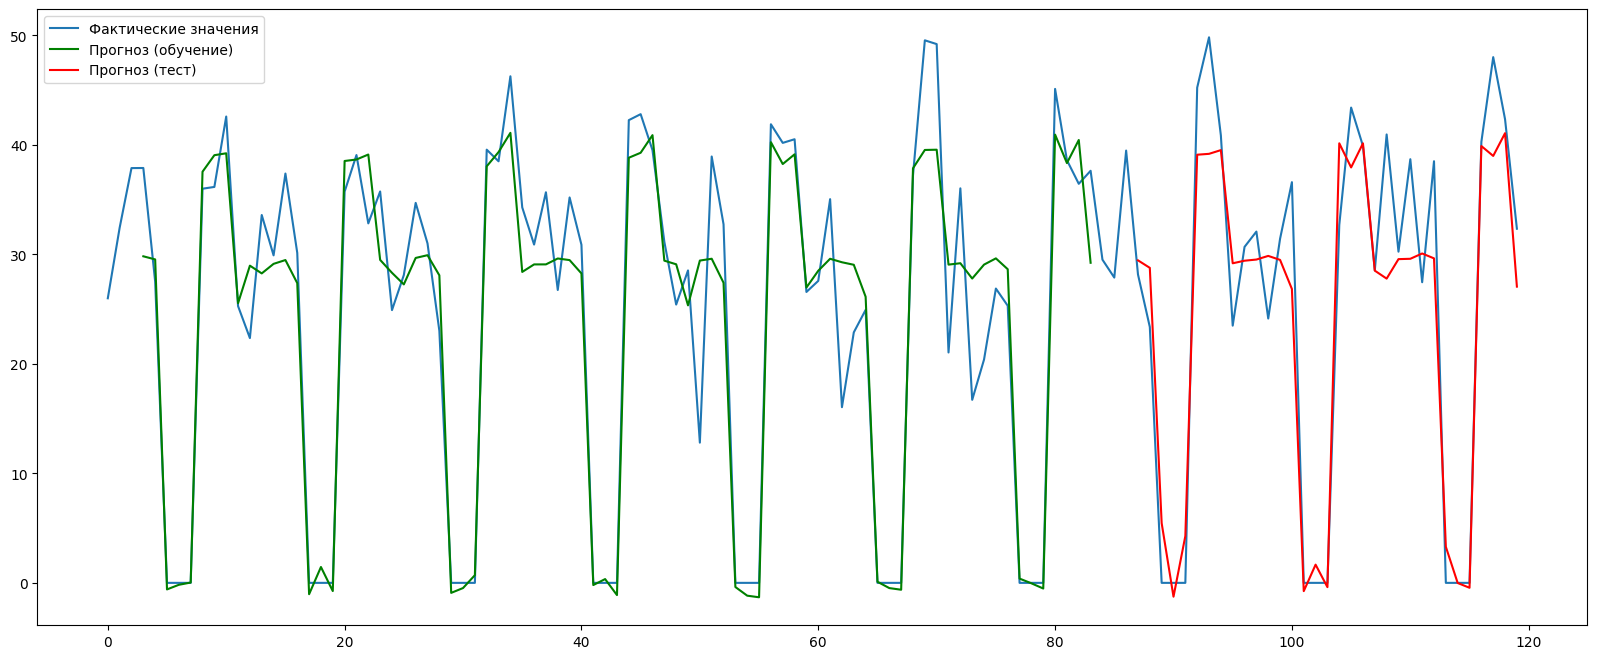

In [28]:
plt.figure(figsize=(20, 8))
plt.plot(scaler.inverse_transform(scaled_features)[:, 0], label='Фактические значения')
plt.plot(np.arange(look_back, len(trainPredict) + look_back), trainPredict, color='g', label='Прогноз (обучение)')
plt.plot(np.arange(len(trainPredict) + 2*look_back, len(scaled_features)), testPredict, color='r', label='Прогноз (тест)')
plt.legend()
plt.show()

In [29]:
evaluate_predictions(trainPredict, testPredict, trainY, testY, scaler_y)

5.389488934015287
0.8677394066418352
4.817062005497867
0.8968289083745894


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

#model.save('/content/drive/MyDrive/моя_папка/lstm_barley_median.h5')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#from keras.models import load_model
#model = load_model('my_model.h5', custom_objects={'r2_score': r2_score})